# Trustworthy recidivism forecasting

Client: a community-supervision software vendor. Compare logistic regression, XGBoost and TabICLv2 for voluntary support prioritization. Target: three-year cumulative new arrest. This differs from NIJ annual conditional forecasting; challenge leaderboard comparisons are invalid.

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
from IPython.display import Image, display
ROOT = Path.cwd()
if not (ROOT / 'artifacts').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from recidivism.data import load_official_split
split = load_official_split()
A = lambda name: pd.read_csv(ROOT / 'artifacts' / name)
print(f'Training: {len(split.X_train):,}; evaluation: {len(split.X_test):,}; features: {split.X_train.shape[1]}')


Training: 18,028; evaluation: 7,807; features: 29


## Reproduce

Run scripts/reproduce.py for the complete pipeline. The evaluation partition is excluded from fitting, but was repeatedly inspected during development. It is not an untouched final holdout. This notebook executes the reporting layer; source scripts provide all fitting/audits.

## Data preparation

Only baseline fields are eligible. Outcomes, IDs, split flags, protected attributes, geography and post-release supervision activities are excluded from model inputs. Imputation and scaling are learned within training pipelines. Logistic uses tuned L1 with one-hot categories; XGBoost ordinal-encodes ordered fields; TabICL mode-imputes categorical missingness before its mixed-data encoder. This neutralizes the gender-aligned `Gang_Affiliated` missingness channel; `scripts/leakage_audit.py` enforces the check.

In [2]:
from recidivism.config import FEATURE_COLUMNS, BASELINE_COLUMNS, DATA_PATH
raw = pd.read_csv(DATA_PATH)
display(pd.Series({'training_target_rate': split.y_train.mean(), 'evaluation_target_rate': split.y_test.mean()}))
display(pd.DataFrame({'feature': raw.columns, 'used_for_scoring': [c in FEATURE_COLUMNS for c in raw.columns]}))
display(raw.assign(gang_missing=raw.Gang_Affiliated.isna()).groupby('Gender').gang_missing.agg(['mean','sum','count']))
display(split.X_train.isna().mean().sort_values(ascending=False).head(10))


training_target_rate      0.578045
evaluation_target_rate    0.574228
dtype: float64

,feature,used_for_scoring
0,ID,False
1,Gender,False
2,Race,False
3,Age_at_Release,True
4,Residence_PUMA,False
5,Gang_Affiliated,True
6,Supervision_Risk_Score_First,True
7,Supervision_Level_First,True
8,Education_Level,True
9,Dependents,True


,mean,sum,count
Gender,,,
F,1.0,3167,3167
M,0.0,0,22668


Prison_Offense                  0.128744
Gang_Affiliated                 0.122975
Supervision_Level_First         0.067229
Supervision_Risk_Score_First    0.018305
Age_at_Release                  0.000000
Education_Level                 0.000000
Dependents                      0.000000
Prison_Years                    0.000000
Prior_Arrest_Episodes_Felony    0.000000
Prior_Arrest_Episodes_Misd      0.000000
dtype: float64

## Performance and baselines

The incumbent is a historical recorded score, not evidence about tools agencies use today. Constant prevalence and incumbent calibration are learned on training records.

In [3]:
display(A('model_metrics.csv')); display(A('validation_baselines.csv'))

,roc_auc,average_precision,brier,log_loss,ece_10,selection_rate,tpr,fnr,fpr,precision,...,model,fit_predict_seconds,economic_capacity,economic_selected,economic_captured_events,economic_recall_at_capacity,economic_precision_at_capacity,economic_assumed_gross_benefit,economic_assumed_program_cost,economic_assumed_net_value
0,0.732807,0.771843,0.204412,0.594506,0.019946,0.679775,0.813072,0.186928,0.500000,0.686829,...,tabicl,41.818326,0.2,1561,1292,0.288200,0.827675,12920000.0,7805000.0,5115000.0
1,0.732364,0.771947,0.204474,0.594530,0.011232,0.678366,0.810618,0.189382,0.500000,0.686178,...,xgboost,8.650971,0.2,1561,1297,0.289315,0.830878,12970000.0,7805000.0,5165000.0
2,0.729833,0.769631,0.205424,0.596697,0.012897,0.677981,0.810841,0.189159,0.498797,0.686756,...,logistic,0.994877,0.2,1561,1285,0.286638,0.823190,12850000.0,7805000.0,5045000.0


,model,roc_auc,average_precision,brier,log_loss,ece_10,selection_rate,tpr,fnr,fpr,precision,accuracy,brier_skill_vs_prevalence
0,logistic,0.729833,0.769631,0.205424,0.596697,0.012897,0.677981,0.810841,0.189159,0.498797,0.686756,0.679006,0.159836
1,xgboost,0.732364,0.771947,0.204474,0.594530,0.011232,0.678366,0.810618,0.189382,0.500000,0.686178,0.678366,0.163724
2,tabicl,0.732807,0.771843,0.204412,0.594506,0.019946,0.679775,0.813072,0.186928,0.500000,0.686829,0.679775,0.163976
3,training_prevalence,0.500000,0.574228,0.244505,0.682117,0.003817,1.000000,1.000000,0.000000,1.000000,0.574228,0.574228,0.000000
4,calibrated_incumbent,0.600481,0.641943,0.237363,0.667524,0.015249,0.745613,0.801249,0.198751,0.670578,0.617076,0.600359,0.029208


## Foundation-model compute sensitivity

The 16-member TabICLv2 configuration is checked on a fixed stratified development slice carved only from the training partition. This is a compute/robustness sensitivity check, not final validation.

,n_estimators,roc_auc,brier,seconds,fit_rows,development_rows
0,1,0.727145,0.205824,6.234756,14422,3606
1,2,0.726366,0.206072,4.251443,14422,3606
2,4,0.727068,0.205672,7.135043,14422,3606
3,8,0.727487,0.205477,13.152294,14422,3606
4,16,0.727927,0.205328,25.418167,14422,3606
5,32,0.727798,0.205356,50.268125,14422,3606
6,64,0.727970,0.205293,99.422606,14422,3606


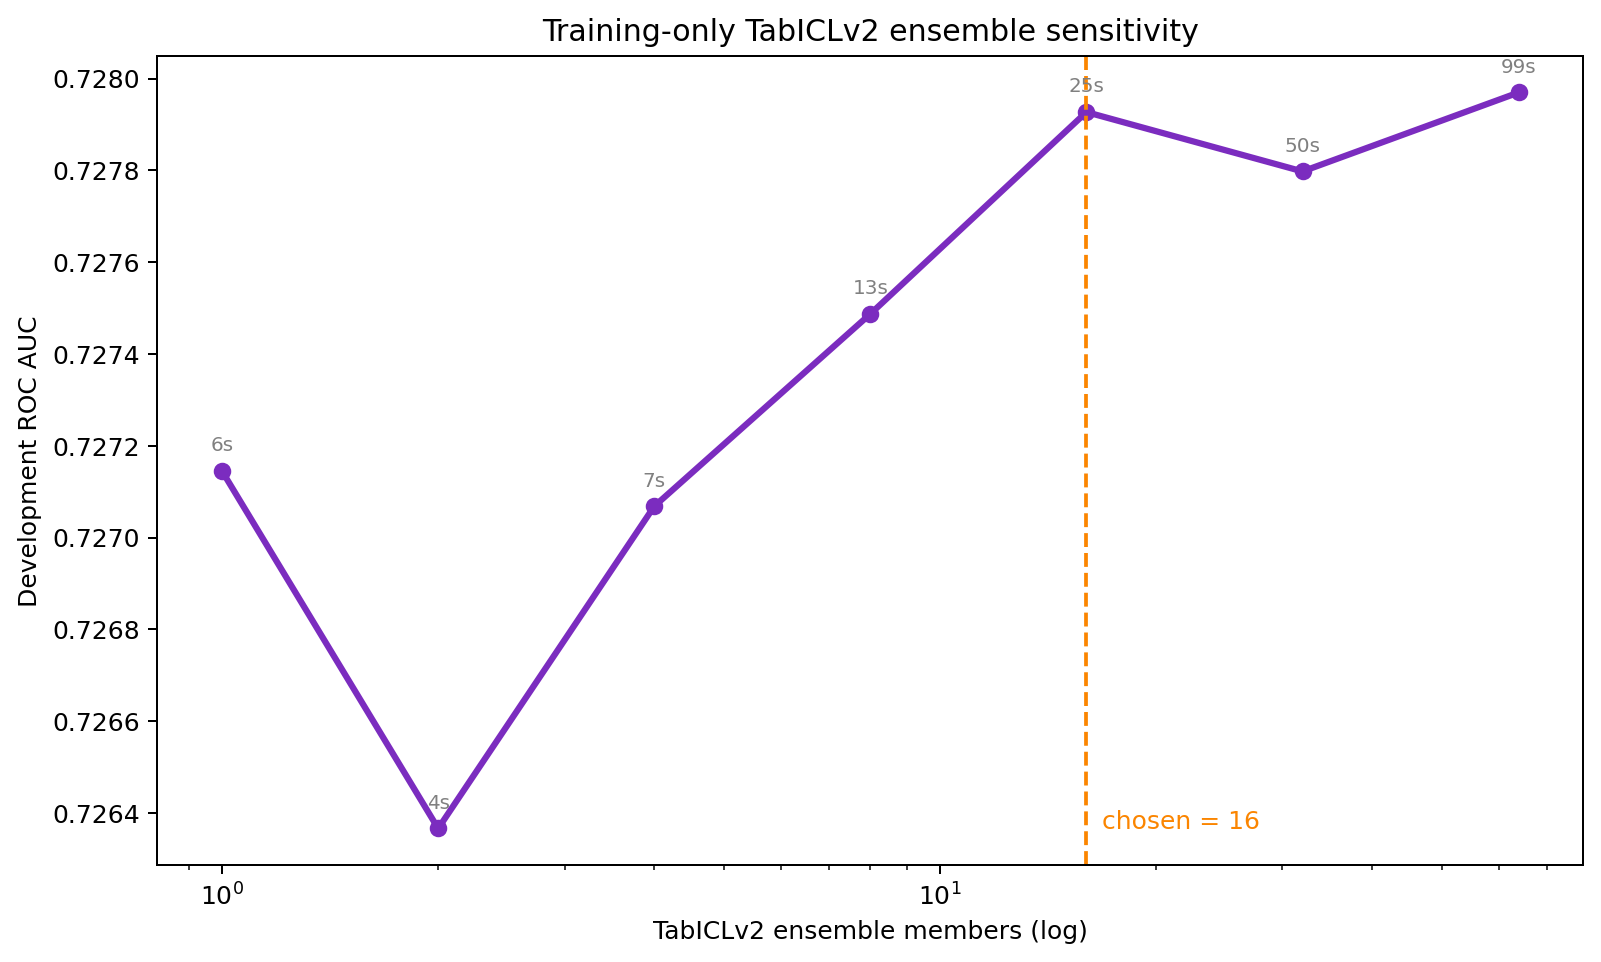

In [4]:
display(A('estimator_sweep.csv')); display(Image(filename=str(ROOT / 'artifacts/figures/estimator_sweep.png'), width=900))

## Paired uncertainty and training CV

Differences are A minus B: positive AUC favors A, negative Brier favors A. Paired bootstrap preserves the correlation between model errors. Marginal intervals are exploratory and unadjusted for development selection or multiple comparisons. Fixed-configuration CV is not nested evaluation of the earlier search.

In [5]:
display(A('paired_comparisons.csv')); display(A('validation_cv.csv').groupby('model')[['roc_auc','brier']].agg(['mean','std']))

,model_a,model_b,metric,difference_a_minus_b,ci_low,ci_high,repeats
0,logistic,xgboost,roc_auc,-0.002531,-0.004354,-0.000607,1000
1,logistic,xgboost,brier,0.000951,0.000331,0.001522,1000
2,logistic,tabicl,roc_auc,-0.002974,-0.005349,-0.000762,1000
3,logistic,tabicl,brier,0.001012,0.000223,0.001873,1000
4,xgboost,tabicl,roc_auc,-0.000443,-0.002299,0.001273,1000
5,xgboost,tabicl,brier,0.000062,-0.000538,0.000720,1000


roc_auc               brier          
              mean       std      mean       std
model                                           
logistic  0.732386  0.005121  0.204398  0.001720
xgboost   0.734344  0.003874  0.203571  0.001381

## Additional leakage and accuracy review

The independent original-release checks and nested accuracy experiments are documented in reports/deep_review.md. Selection occurs on inner folds; outer folds score the selected configuration. Historical defaults already saw this training cohort, so these scores do not replace new-cohort validation. A fixed equal-weight ensemble is a research challenger.

In [6]:
review = ROOT / 'artifacts/deep_review/combined_summary.csv'
if review.exists(): display(pd.read_csv(review))

,model,roc_auc,brier,log_loss,accuracy
0,blend_equal,0.735075,0.203378,0.592683,0.679831
1,tabicl,0.735250,0.203478,0.593222,0.682827
2,xgboost_calibrated,0.733567,0.203850,0.593747,0.679942
3,xgboost_native,0.733624,0.203854,0.593727,0.681551
4,xgboost_current,0.733567,0.203862,0.593757,0.680441
5,xgboost_selected,0.733567,0.203862,0.593757,0.680441
6,catboost_native,0.733579,0.203871,0.593894,0.680164
7,logistic,0.732432,0.204353,0.595048,0.681662


## Economic scenarios

Effectiveness and costs are assumed, not estimated causal savings. Exact capacity uses stable row-order ties; this matters particularly for the discrete incumbent.

In [7]:
display(A('incumbent_economics.csv'))

,ranker,capacity,selected,captured_events,recall_at_capacity,precision_at_capacity,assumed_gross_benefit,assumed_program_cost,assumed_net_value
0,random,0.2,1561,926,0.206558,0.593209,9260000.0,7805000.0,1455000.0
1,incumbent,0.2,1561,1053,0.234887,0.674568,10530000.0,7805000.0,2725000.0
2,logistic,0.2,1561,1285,0.286638,0.823190,12850000.0,7805000.0,5045000.0
3,xgboost,0.2,1561,1297,0.289315,0.830878,12970000.0,7805000.0,5165000.0
4,tabicl,0.2,1561,1292,0.288200,0.827675,12920000.0,7805000.0,5115000.0


## Interpretability

SHAP and LIME explain conventional models; XPER approximates performance attribution on a small sample. Surrogate fidelity is imperfect. TabICLv2 has PDP/ICE, permutation and interactive sensitivity, but no implemented native additive attribution. These are model-response explanations, not causal effects.

In [8]:
display(A('shap_importance.csv').groupby('model').head(8)); display(A('xper_values.csv')); display(json.loads((ROOT/'artifacts/interpretability_summary.json').read_text()))

,model,feature,mean_abs_shap
0,logistic,Age_at_Release,0.443735
1,logistic,Gang_Affiliated,0.231156
2,logistic,Prior_Arrest_Episodes_Felony,0.215080
3,logistic,Prison_Years,0.147778
4,logistic,_v1,0.143114
5,logistic,Prior_Arrest_Episodes_Property,0.128136
6,logistic,Prior_Arrest_Episodes_Misd,0.118728
7,logistic,Condition_MH_SA,0.116415
29,xgboost,Age_at_Release,0.394702
30,xgboost,Gang_Affiliated,0.205315


,model,feature,xper,sample_auc
0,logistic,benchmark (uninformative model),0.476419,0.721680
1,logistic,Age_at_Release,0.088881,0.721680
2,logistic,Gang_Affiliated,0.024831,0.721680
3,logistic,Supervision_Risk_Score_First,0.007992,0.721680
4,logistic,Supervision_Level_First,0.002482,0.721680
5,logistic,Education_Level,-0.004950,0.721680
6,logistic,Dependents,-0.000741,0.721680
7,logistic,Prison_Offense,0.003749,0.721680
8,logistic,Prison_Years,0.008470,0.721680
9,logistic,Prior_Arrest_Episodes_Felony,0.043153,0.721680


{'logistic_individual_probability': 0.949590146795122,
 'xgboost_individual_probability': 0.937201738357544,
 'surrogate_depth': 3,
 'surrogate_fidelity_r2_test': 0.6095788334531511,
 'lime': 'ok (features shown in scaled, preprocessed space)',
 'lime_local_surrogate_r2': 0.25027814999297615,
 'tabicl_native_attribution': 'none: explained only through model-agnostic PDP/ICE and permutation importance'}

The approximate XPER contributions do not exactly reconstruct the sample AUC; the discrepancy is reported below and its numerical cause has not been isolated.

In [9]:
diagnostics = ROOT / 'artifacts/xper_diagnostics.csv'
if diagnostics.exists(): display(pd.read_csv(diagnostics))

,model,contribution_sum,sample_auc,reconstruction_residual
0,logistic,0.739600,0.721680,0.017920
1,xgboost,0.750737,0.727943,0.022795


Logistic odds ratios below are per transformed unit (numeric inputs are standardized), not causal effects. Local sensitivity changes one field of the same explained person for all three models; it is not an additive attribution.

In [10]:
display(A('logistic_coefficients.csv')); display(A('local_sensitivity.csv'))

,feature,coefficient,odds_ratio_per_transformed_unit,nonzero
0,Supervision_Risk_Score_First,0.087123,1.091031,True
1,missingindicator_Supervision_Risk_Score_First,0.014612,1.014719,True
2,Age_at_Release_18-22,1.141240,3.130649,True
3,Age_at_Release_23-27,0.712769,2.039632,True
4,Age_at_Release_28-32,0.311367,1.365290,True
...,...,...,...,...
103,Condition_MH_SA_Yes,0.102273,1.107685,True
104,Condition_Cog_Ed_No,0.013213,1.013300,True
105,Condition_Cog_Ed_Yes,0.000000,1.000000,False
106,Condition_Other_No,-0.017663,0.982492,True


,model,feature,value,original_value,baseline_probability,changed_probability,change
0,logistic,Age_at_Release,18-22,33-37,0.949590,0.983326,0.033736
1,logistic,Age_at_Release,23-27,33-37,0.949590,0.974633,0.025043
2,logistic,Age_at_Release,28-32,33-37,0.949590,0.962573,0.012983
3,logistic,Age_at_Release,33-37,33-37,0.949590,0.949590,0.000000
4,logistic,Age_at_Release,38-42,33-37,0.949590,0.942319,-0.007271
...,...,...,...,...,...,...,...
79,tabicl,Supervision_Risk_Score_First,6.0,9.0,0.951519,0.944610,-0.006909
80,tabicl,Supervision_Risk_Score_First,7.0,9.0,0.951519,0.946947,-0.004572
81,tabicl,Supervision_Risk_Score_First,8.0,9.0,0.951519,0.950252,-0.001267
82,tabicl,Supervision_Risk_Score_First,9.0,9.0,0.951519,0.951519,0.000000


## Stability

Jaccard is intersection/union, not the fraction of people retaining status. At equal selected-set size, replaced fraction is (1-J)/(1+J). Refits do not measure temporal stability; pairwise comparisons share refits.

In [11]:
stability = A('stability_summary.csv'); stability['selected_set_replacement'] = (1-stability.top20_jaccard)/(1+stability.top20_jaccard); display(stability)

,model,mean_abs_prob_diff,p95_abs_prob_diff,rank_correlation,top20_jaccard,refits,selected_set_replacement
0,logistic,0.0322,0.0836,0.9754,0.7725,8,0.128350
1,tabicl,0.0362,0.0931,0.9711,0.7698,8,0.130071
2,xgboost,0.0346,0.0900,0.9713,0.7548,8,0.139731


## Fairness

Thresholds change decisions, not calibration of unchanged probabilities. Equal FPR alone is not equalized odds. The group-threshold frontier optimizes using evaluation labels: an optimistic in-sample illustration, not validated mitigation. Removing race does not remove proxies or prove counterfactual fairness.

In [12]:
display(A('fairness_inference.csv')); display(A('intersectional_audit.csv')); display(A('race_ab_test.csv'))

,model,attribute,comparison,rule,metric,gap,ci_low,ci_high,significant
0,logistic,Race,BLACK minus WHITE,threshold_0.5,selection_rate,0.039474,0.017832,0.059973,True
1,logistic,Race,BLACK minus WHITE,threshold_0.5,tpr,0.017325,-0.005087,0.041072,False
2,logistic,Race,BLACK minus WHITE,threshold_0.5,fpr,0.056218,0.019163,0.090911,True
3,logistic,Race,BLACK minus WHITE,threshold_0.5,fnr,-0.017325,-0.041072,0.005087,False
4,logistic,Race,BLACK minus WHITE,threshold_0.5,precision,-0.004386,-0.029983,0.023204,False
5,logistic,Race,BLACK minus WHITE,top_20pct,selection_rate,0.014432,-0.001526,0.033832,False
6,logistic,Race,BLACK minus WHITE,top_20pct,tpr,0.004729,-0.018970,0.031631,False
7,logistic,Race,BLACK minus WHITE,top_20pct,fpr,0.019017,-0.000976,0.035999,False
8,logistic,Race,BLACK minus WHITE,top_20pct,fnr,-0.004729,-0.031631,0.018970,False
9,logistic,Race,BLACK minus WHITE,top_20pct,precision,-0.020951,-0.056924,0.018888,False


,roc_auc,average_precision,brier,log_loss,ece_10,selection_rate,tpr,fnr,fpr,precision,accuracy,attribute,group,n,base_rate,model
0,0.717752,0.762782,0.208893,0.605405,0.014993,0.694530,0.817975,0.182025,0.522931,0.684979,0.675342,Race,BLACK,4534,0.581606,logistic
1,0.745860,0.779978,0.200618,0.584635,0.016617,0.655057,0.800650,0.199350,0.466713,0.689366,0.684082,Race,WHITE,3273,0.564009,logistic
2,0.754346,0.701277,0.206218,0.599020,0.079229,0.565263,0.763341,0.236659,0.400771,0.612663,0.673684,Gender,F,950,0.453684,logistic
3,0.723259,0.776033,0.205314,0.596375,0.013775,0.693598,0.815893,0.184107,0.516934,0.695122,0.679743,Gender,M,6857,0.590929,logistic
4,0.788818,0.739697,0.197527,0.578438,0.105970,0.557522,0.797203,0.202797,0.382653,0.603175,0.693215,Race x Gender,BLACK / F,339,0.421829,logistic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,0.569571,0.652731,0.236622,0.665894,0.008178,0.889106,0.907027,0.092973,0.861842,0.615554,0.602087,Age at release,28-32,1533,0.603392,calibrated_incumbent
71,0.553185,0.613737,0.244967,0.683007,0.038822,0.746142,0.763265,0.236735,0.723708,0.580145,0.552469,Age at release,33-37,1296,0.567130,calibrated_incumbent
72,0.584345,0.580794,0.246203,0.685579,0.043637,0.627492,0.680328,0.319672,0.572043,0.555184,0.557188,Age at release,38-42,953,0.512067,calibrated_incumbent
73,0.579698,0.565565,0.246748,0.687205,0.038497,0.496063,0.565217,0.434783,0.423181,0.584656,0.570866,Age at release,43-47,762,0.513123,calibrated_incumbent


,model,variant,roc_auc,twin_mean_abs_diff,twin_mean_diff_B_minus_W,twin_max_abs_diff,selection_gap_B_minus_W,fpr_gap_B_minus_W,tpr_gap_B_minus_W,mean_p_gap_B_minus_W
0,logistic,A_with_race,0.729776,0.005628,0.005628,0.006871,0.024427,0.023408,0.019030,0.023455
1,logistic,B_without_race,0.729833,0.000000,0.000000,0.000000,0.014432,0.019017,0.004729,0.018611
2,xgboost,A_with_race,0.732866,0.008330,0.006812,0.041364,0.023901,0.020053,0.020222,0.025231
3,xgboost,B_without_race,0.732364,0.000000,0.000000,0.000000,0.022849,0.022515,0.016647,0.020243
4,tabicl,A_with_race,0.733768,0.009262,0.005737,0.045654,0.026006,0.020586,0.023635,0.026741
5,tabicl,B_without_race,0.732807,0.000000,0.000000,0.000000,0.027058,0.023923,0.023039,0.022144


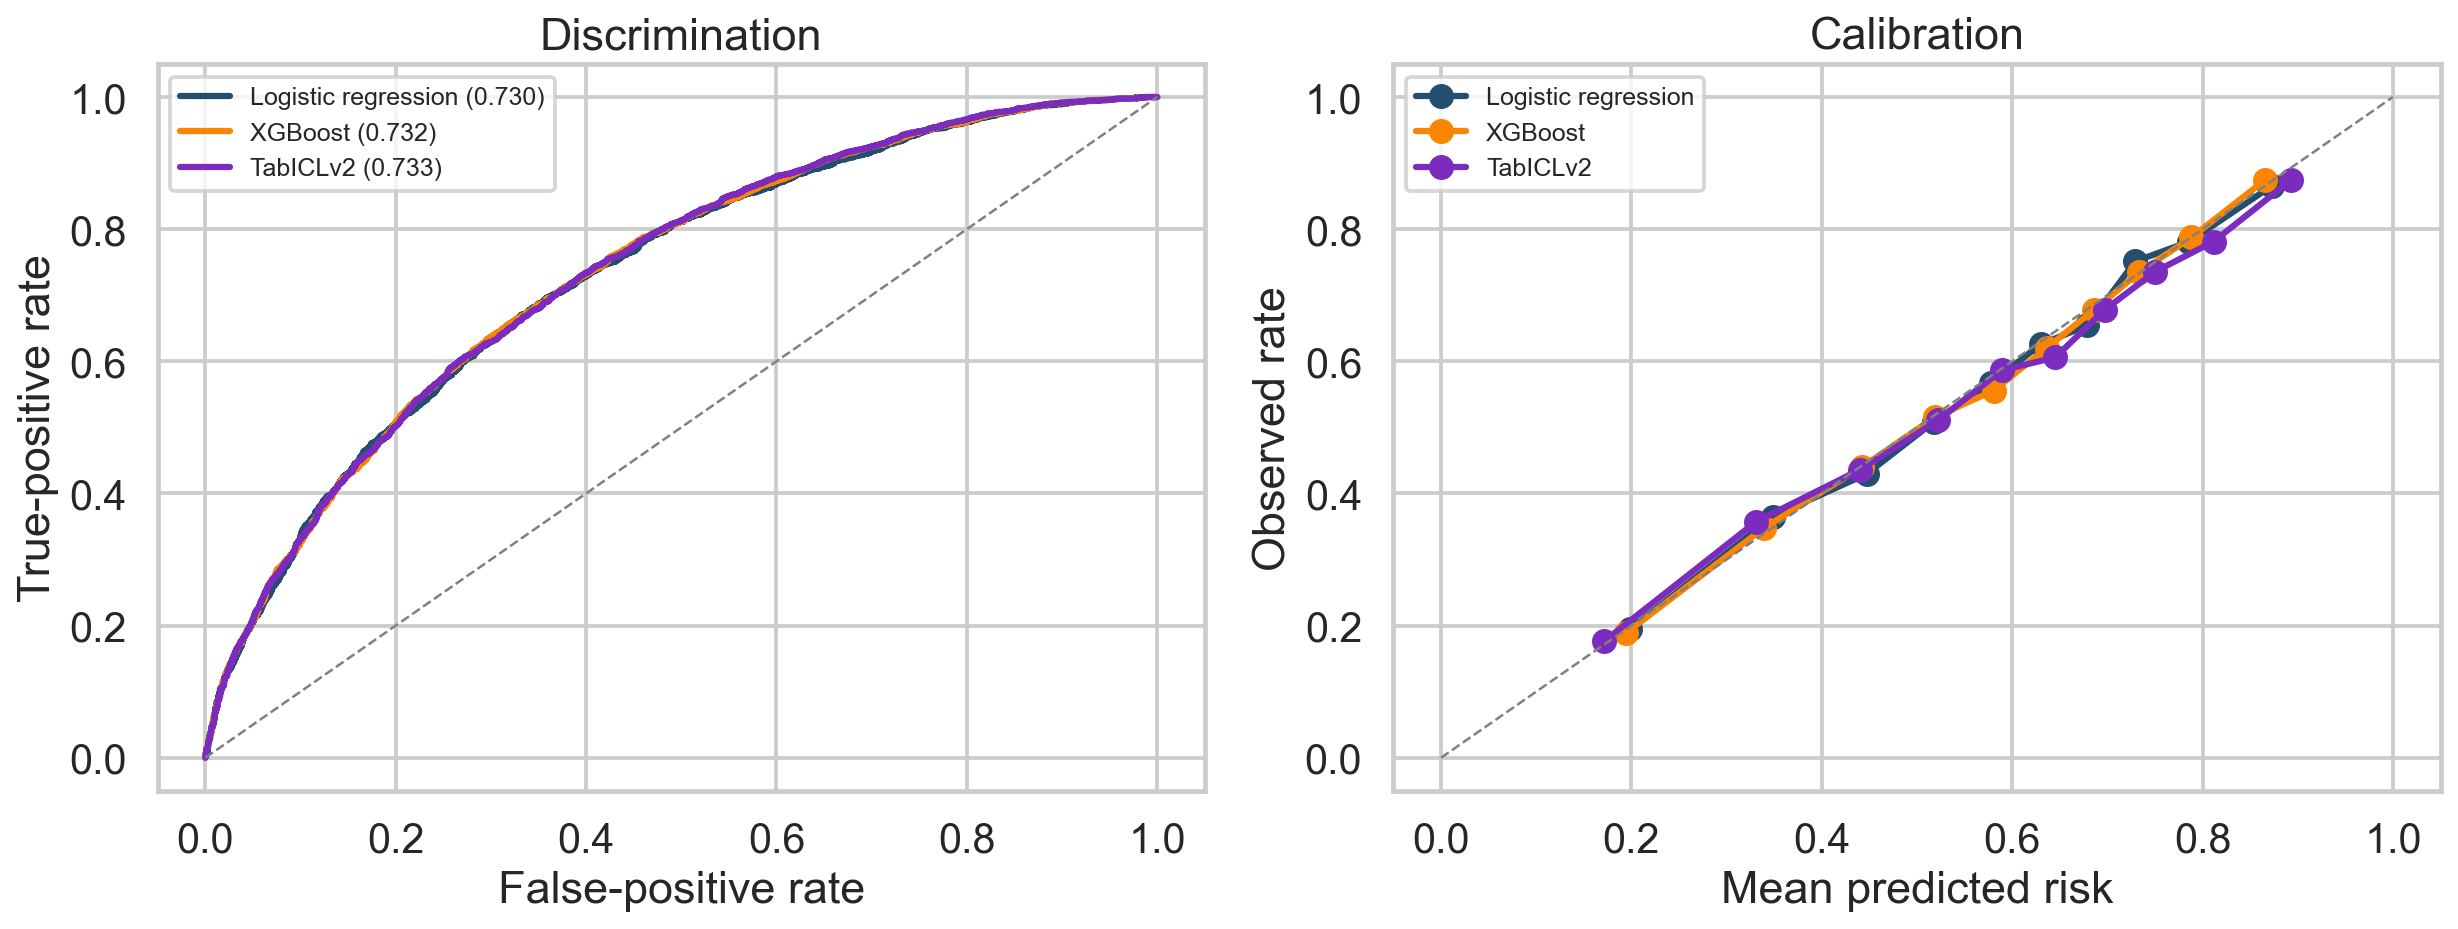

In [13]:
display(Image(filename=str(ROOT / 'artifacts/figures/performance_calibration.png'), width=1000))

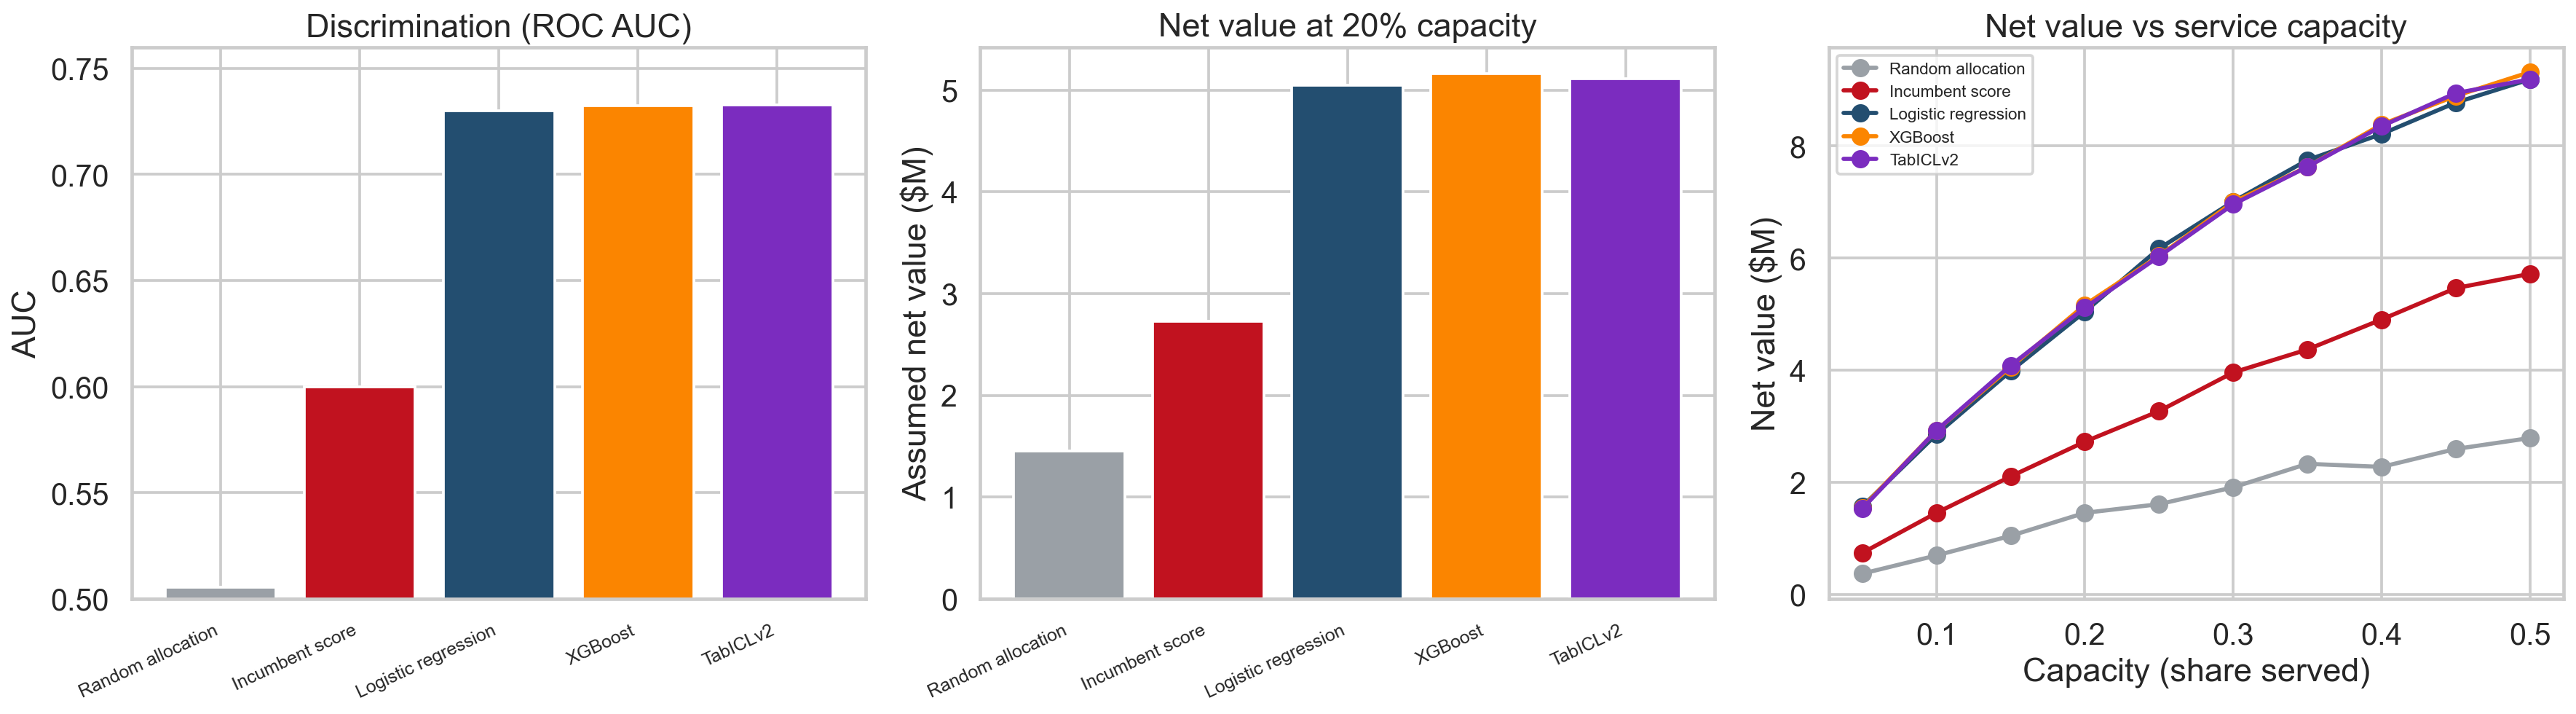

In [14]:
display(Image(filename=str(ROOT / 'artifacts/figures/incumbent_benchmark.png'), width=1000))

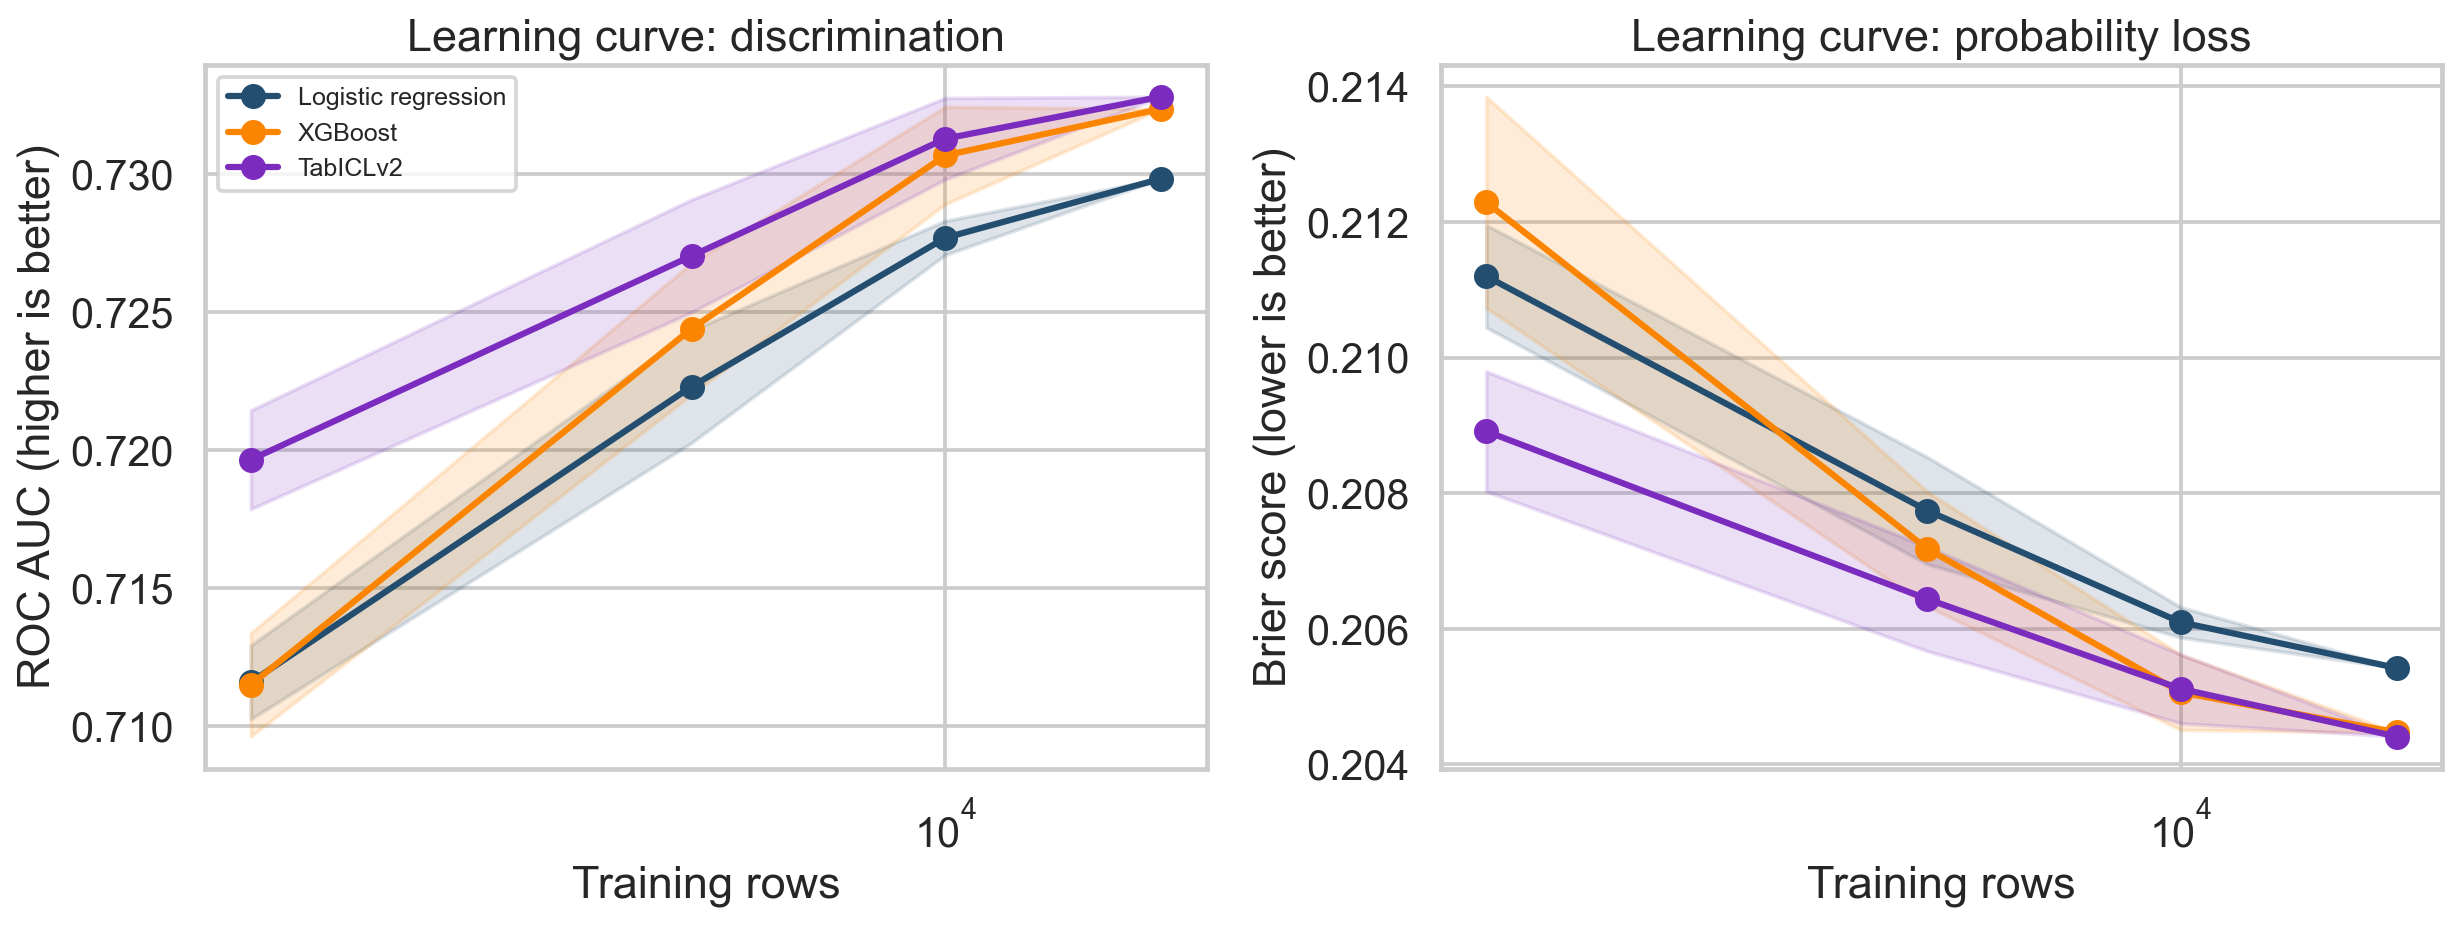

In [15]:
display(Image(filename=str(ROOT / 'artifacts/figures/learning_curve.png'), width=1000))

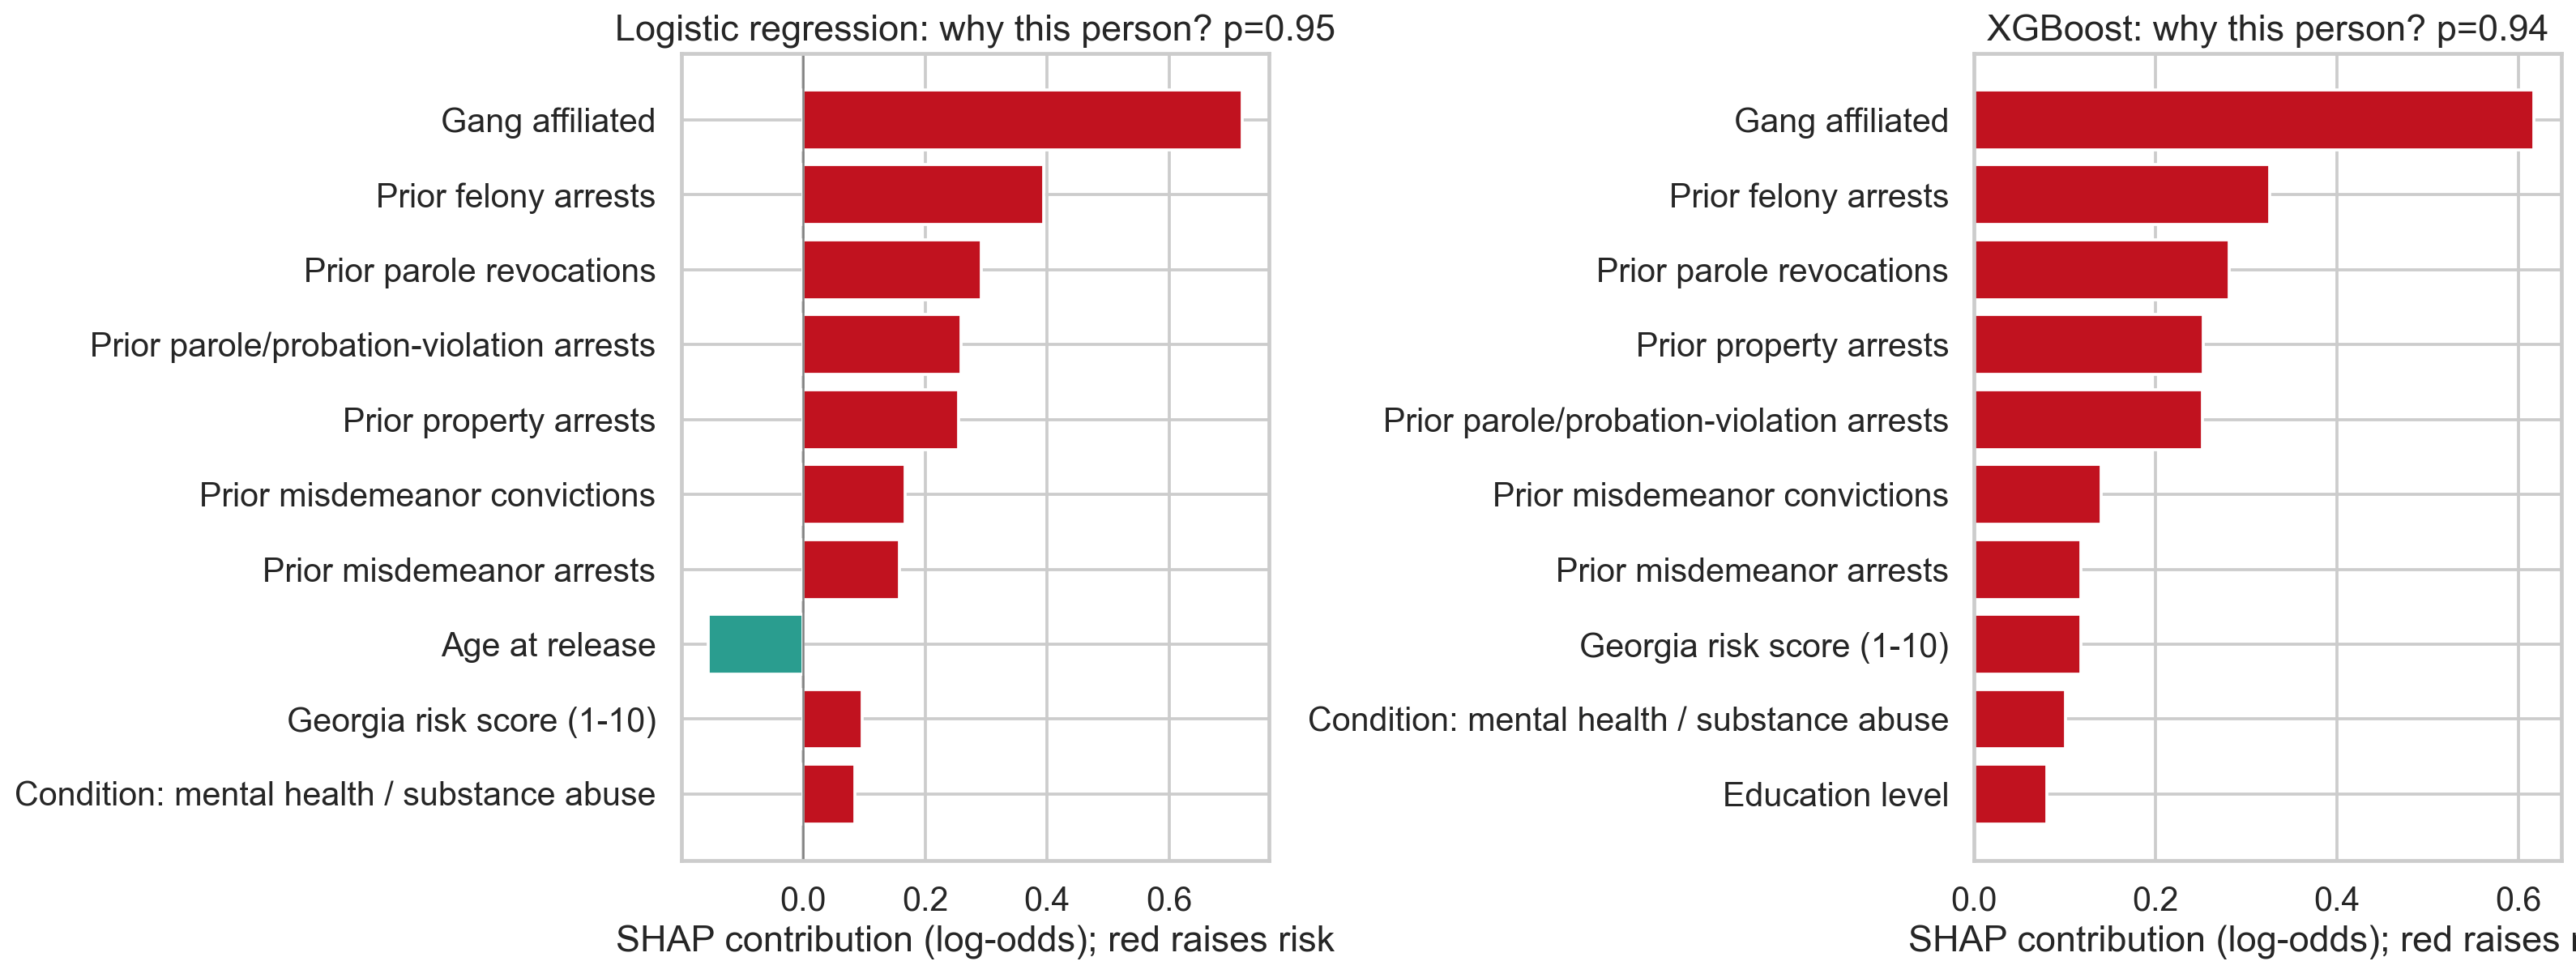

In [16]:
display(Image(filename=str(ROOT / 'artifacts/figures/shap_individual.png'), width=1000))

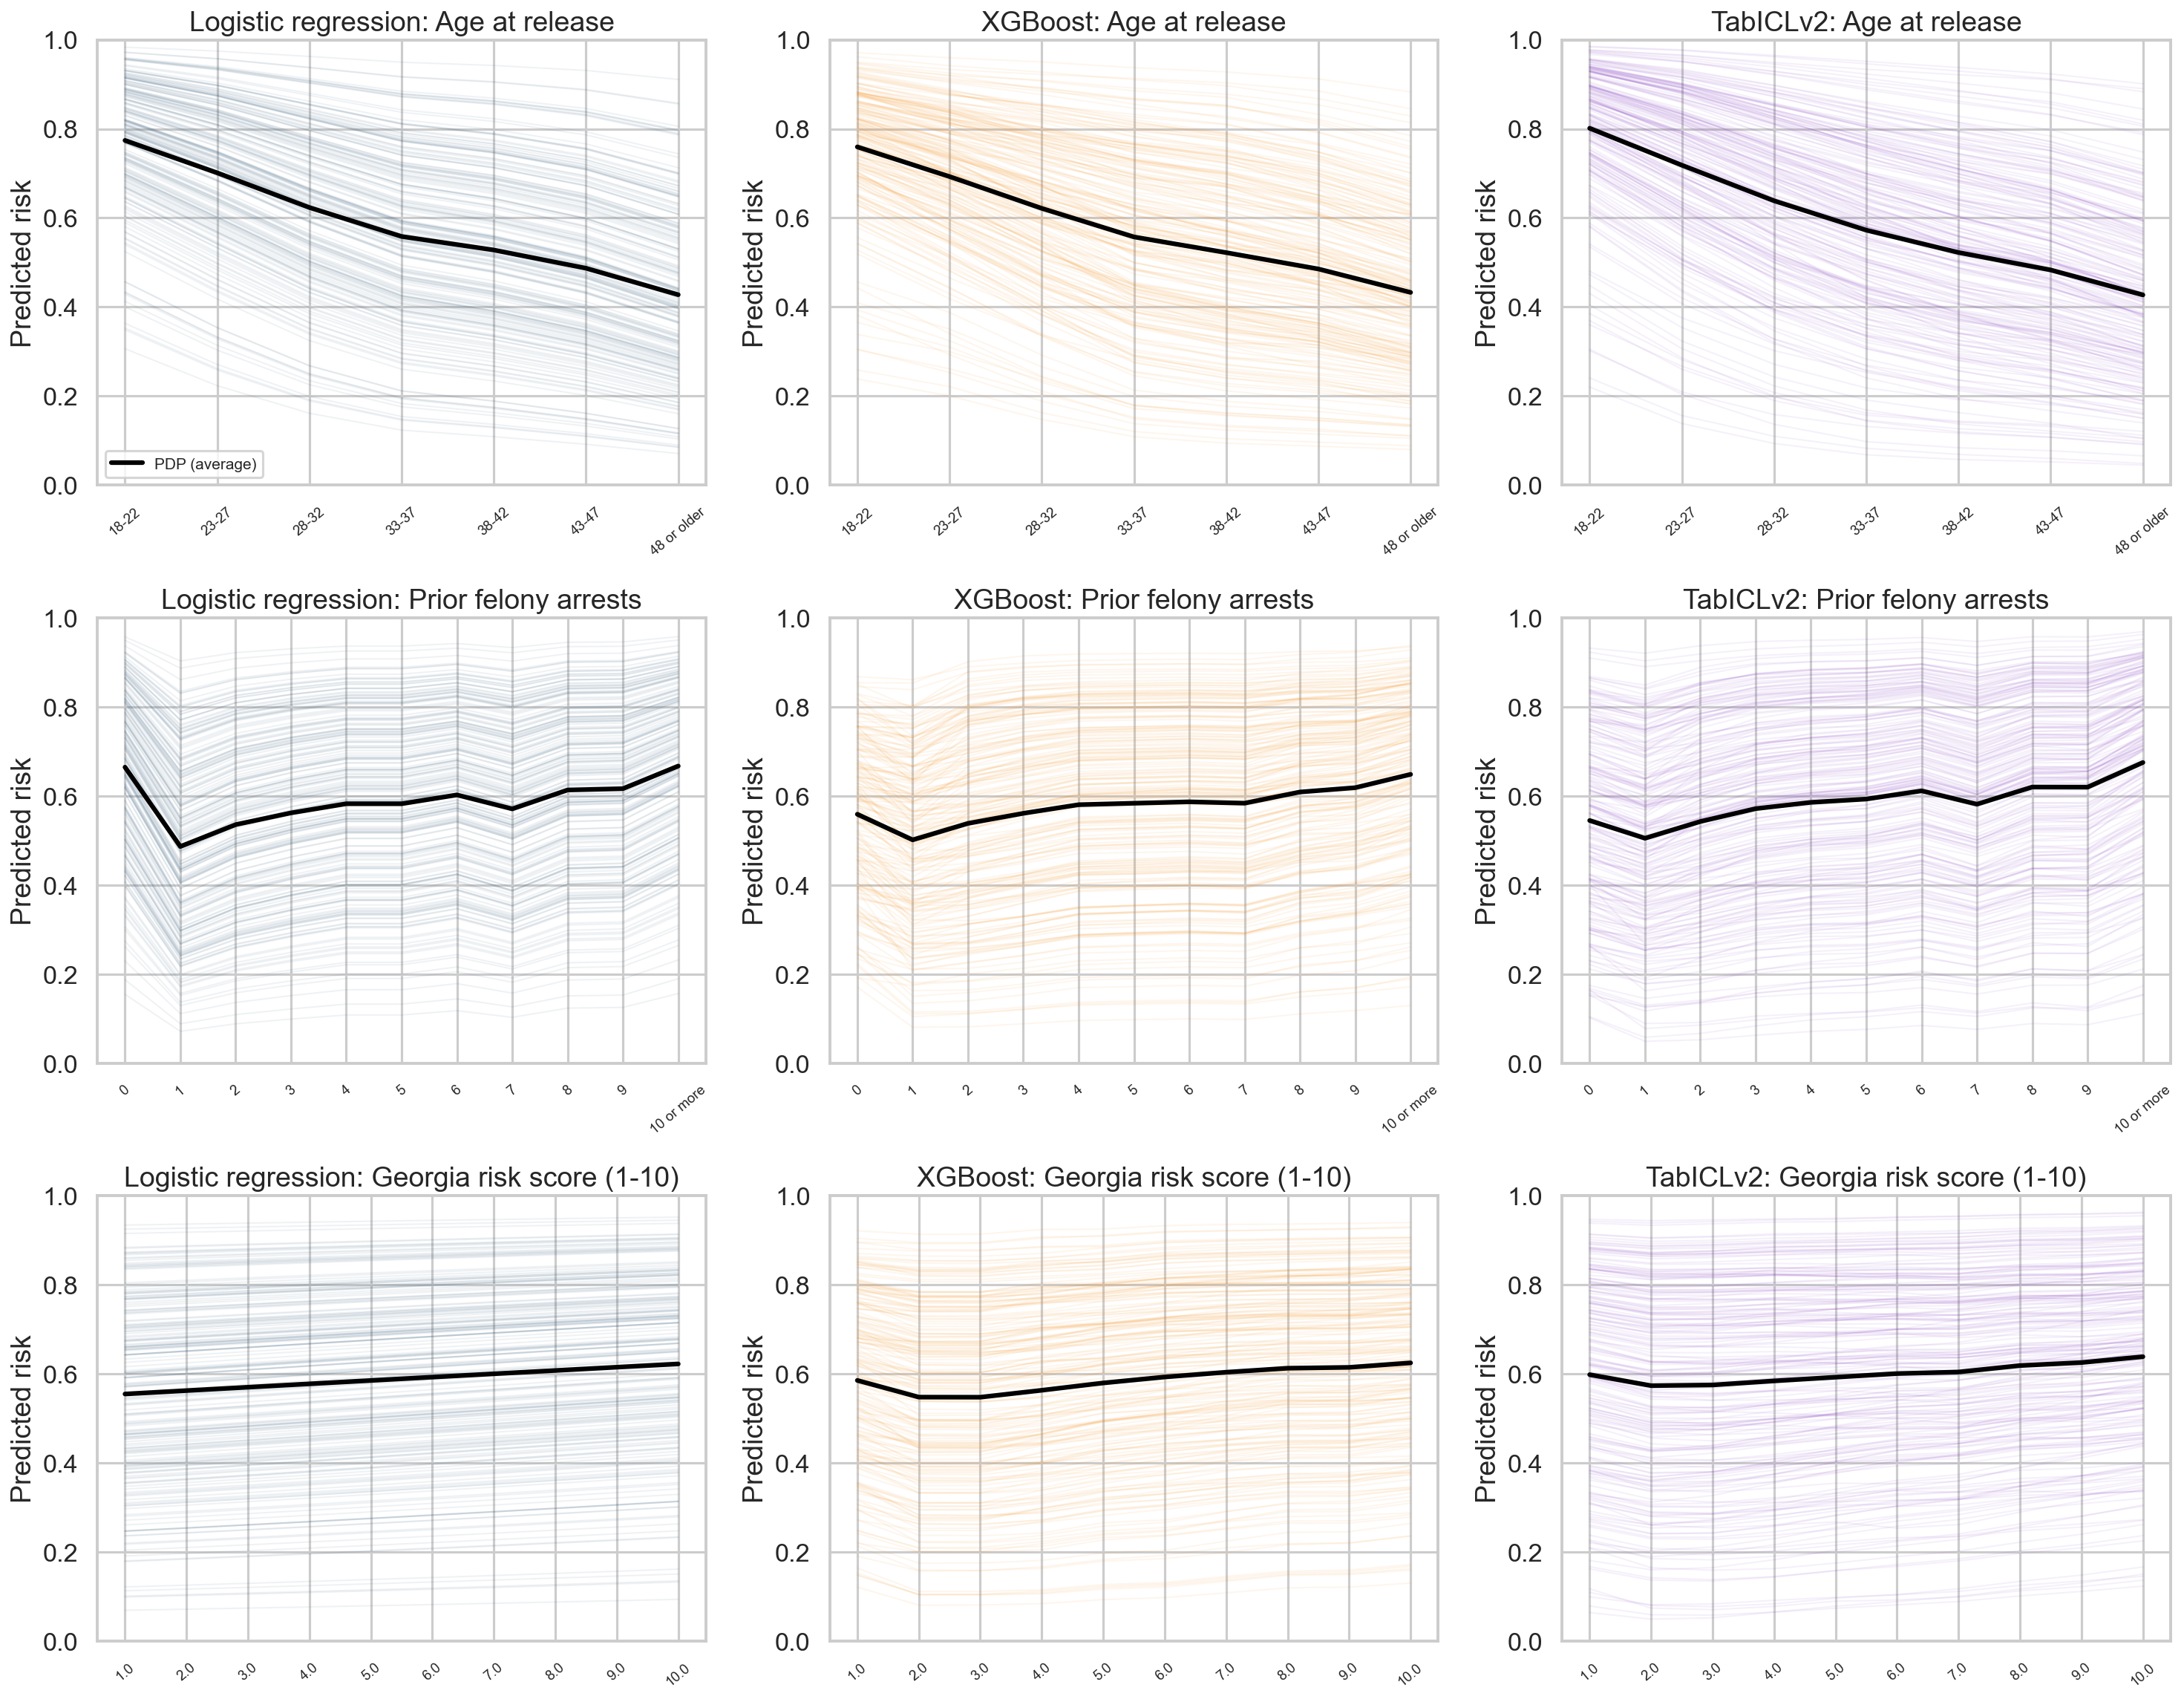

In [17]:
display(Image(filename=str(ROOT / 'artifacts/figures/pdp_ice.png'), width=1000))

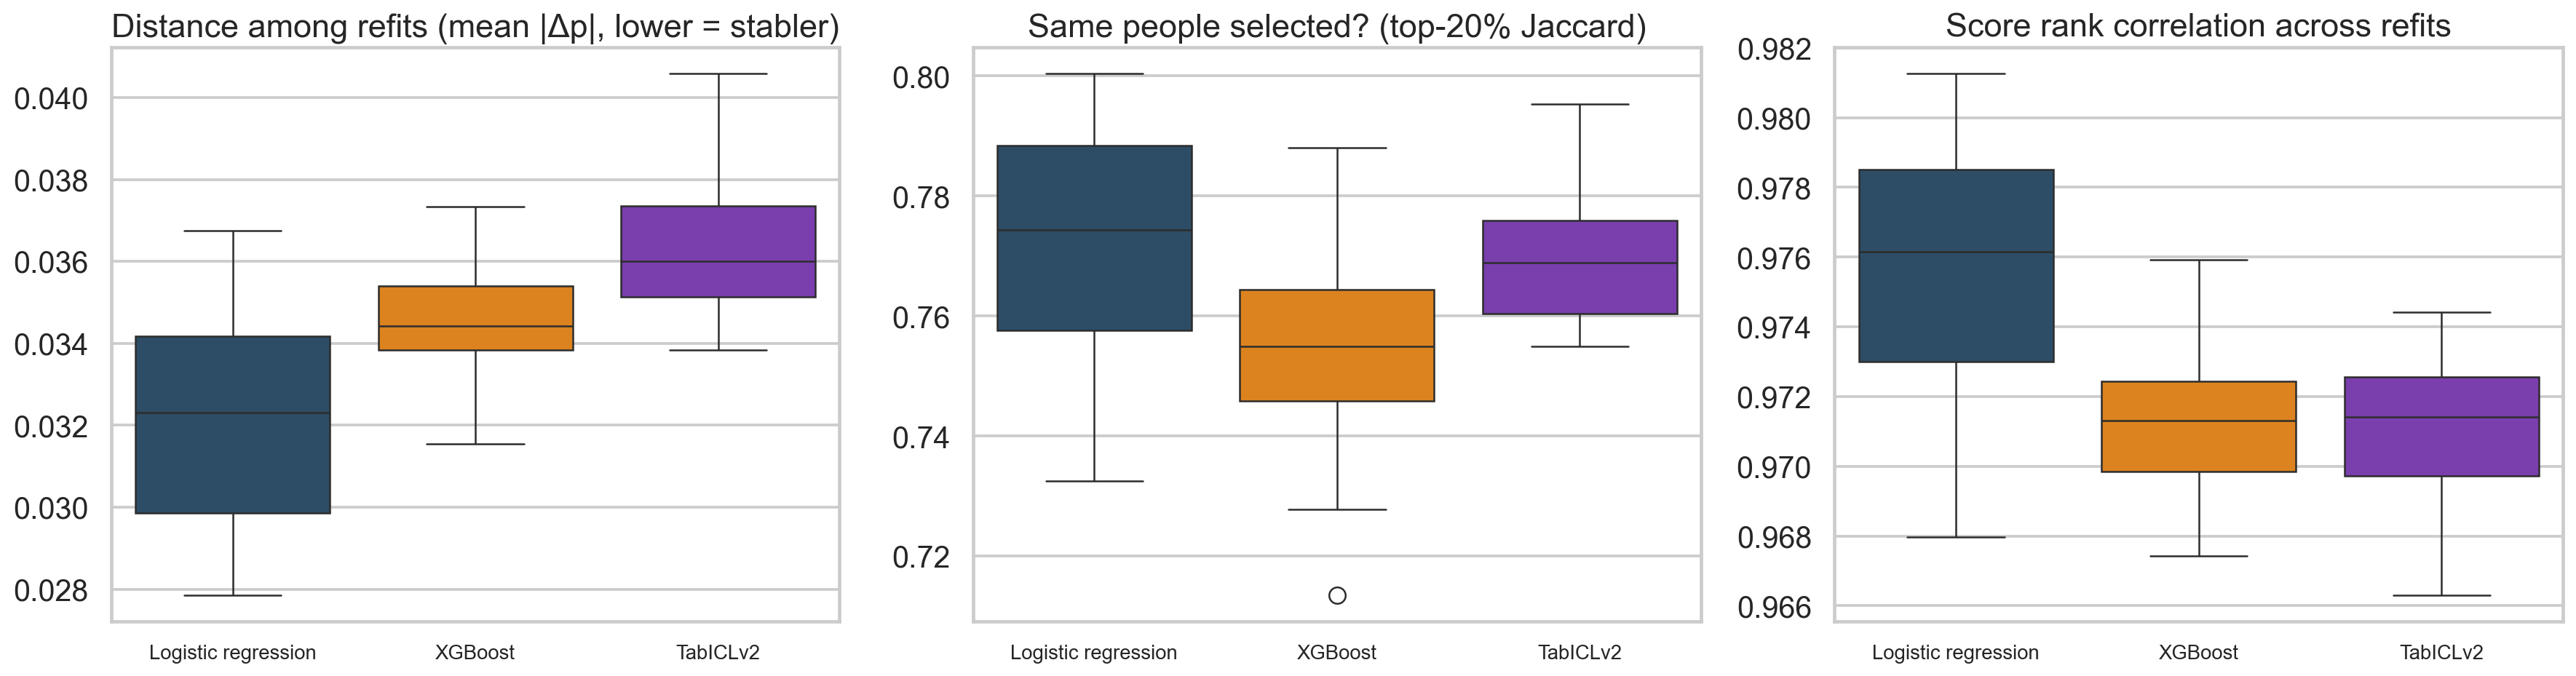

In [18]:
display(Image(filename=str(ROOT / 'artifacts/figures/structural_stability.png'), width=1000))

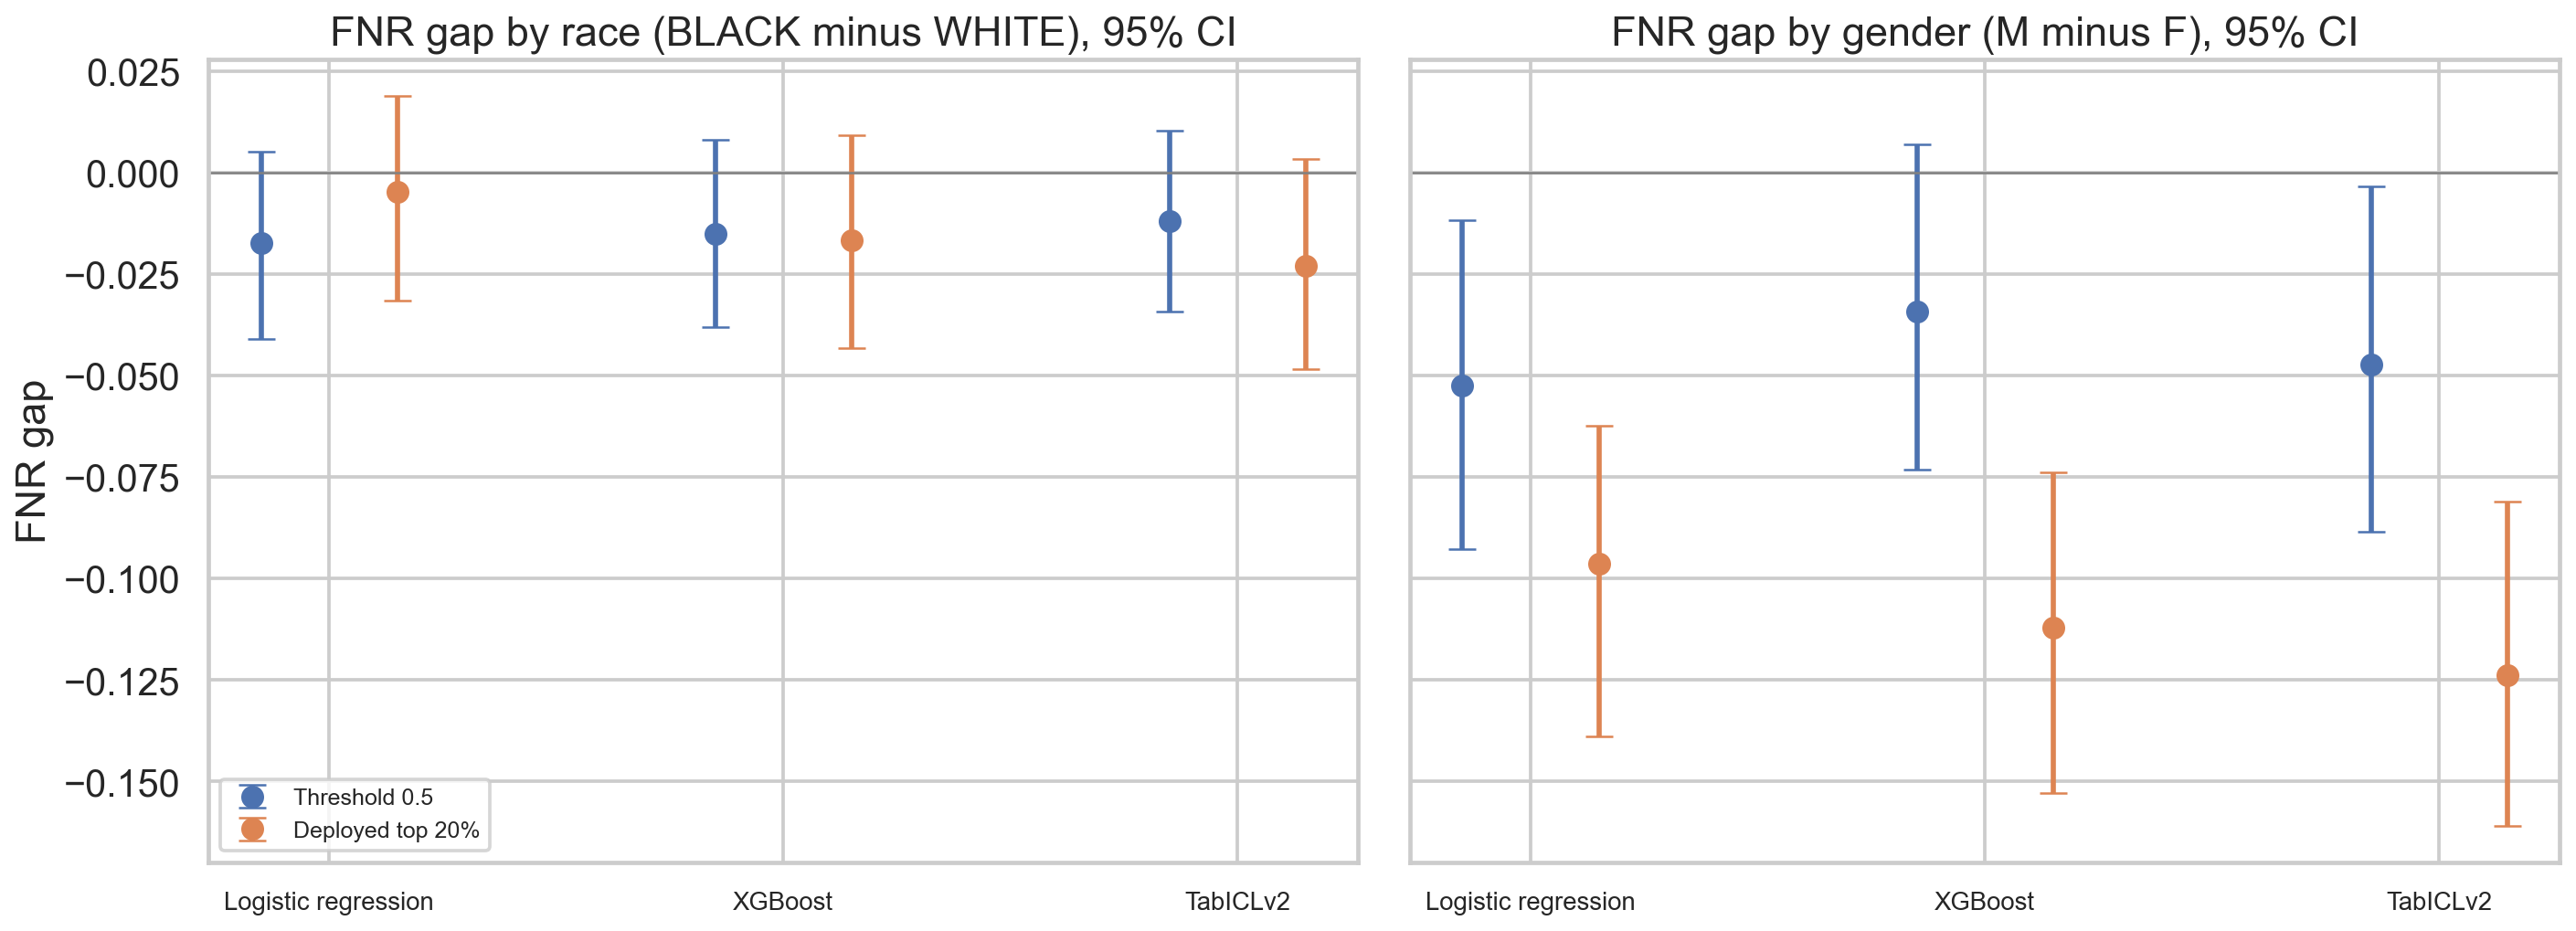

In [19]:
display(Image(filename=str(ROOT / 'artifacts/figures/fairness_support_access.png'), width=1000))

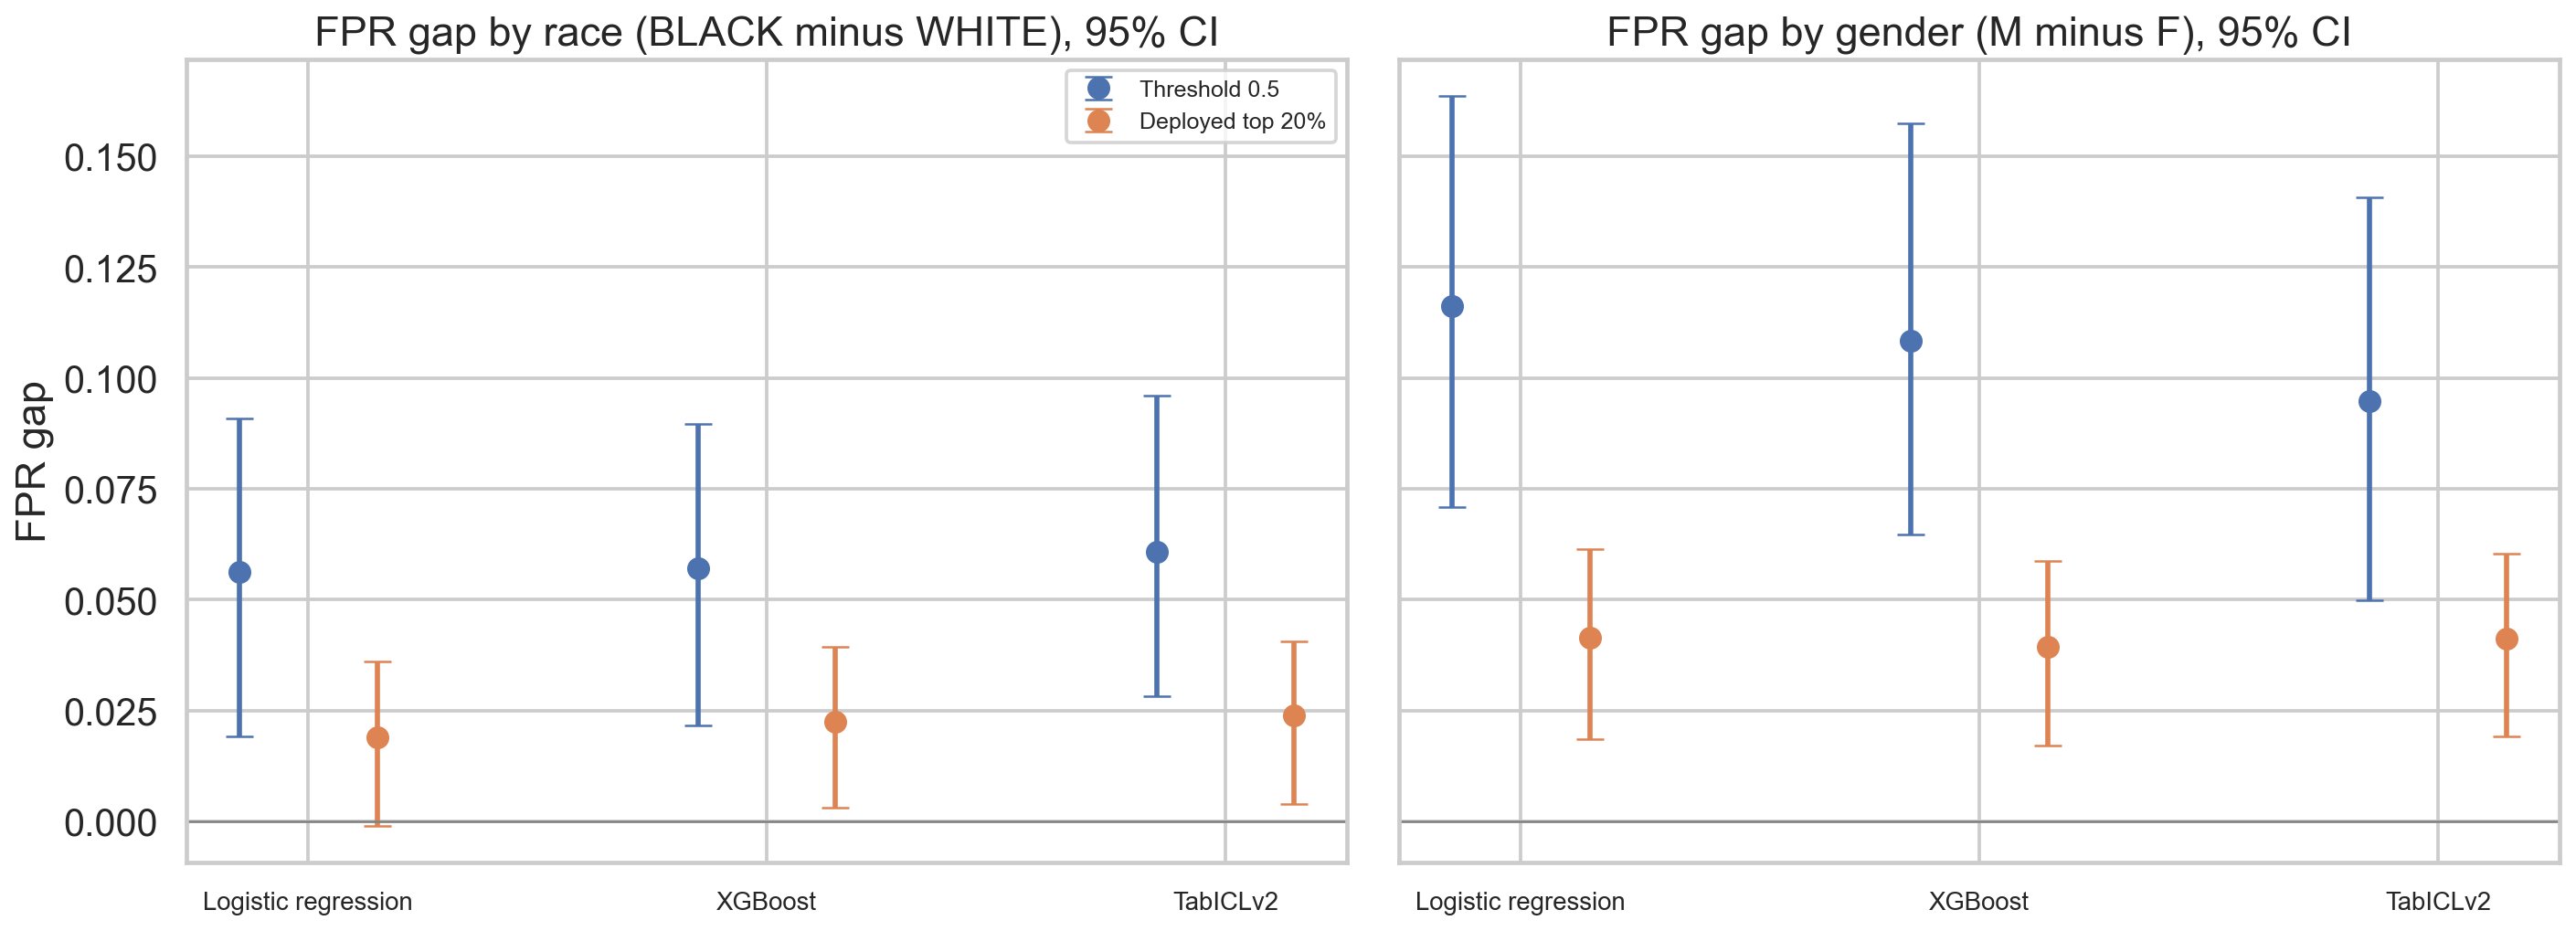

In [20]:
display(Image(filename=str(ROOT / 'artifacts/figures/fairness_operating_point.png'), width=1000))

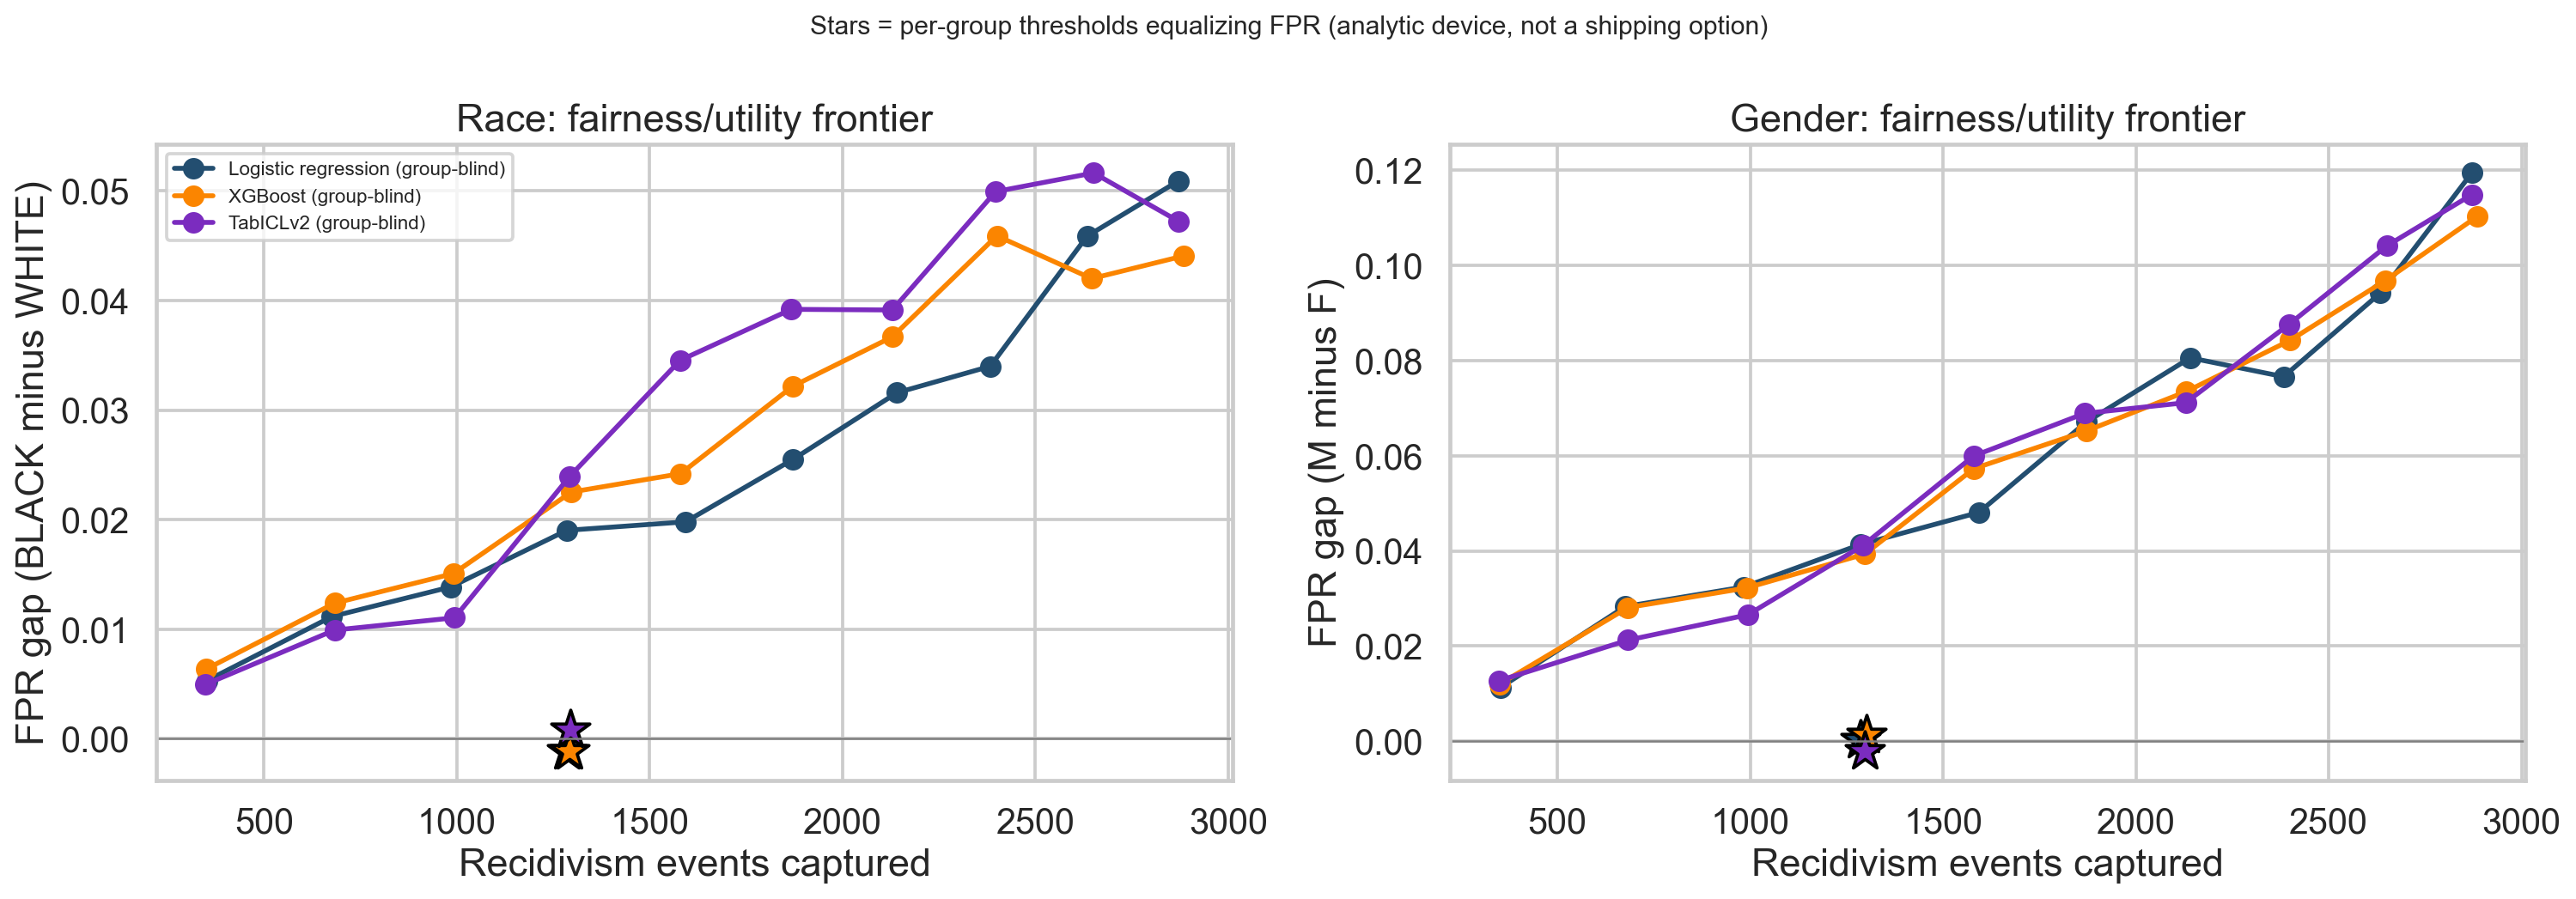

In [21]:
display(Image(filename=str(ROOT / 'artifacts/figures/fairness_frontier.png'), width=1000))

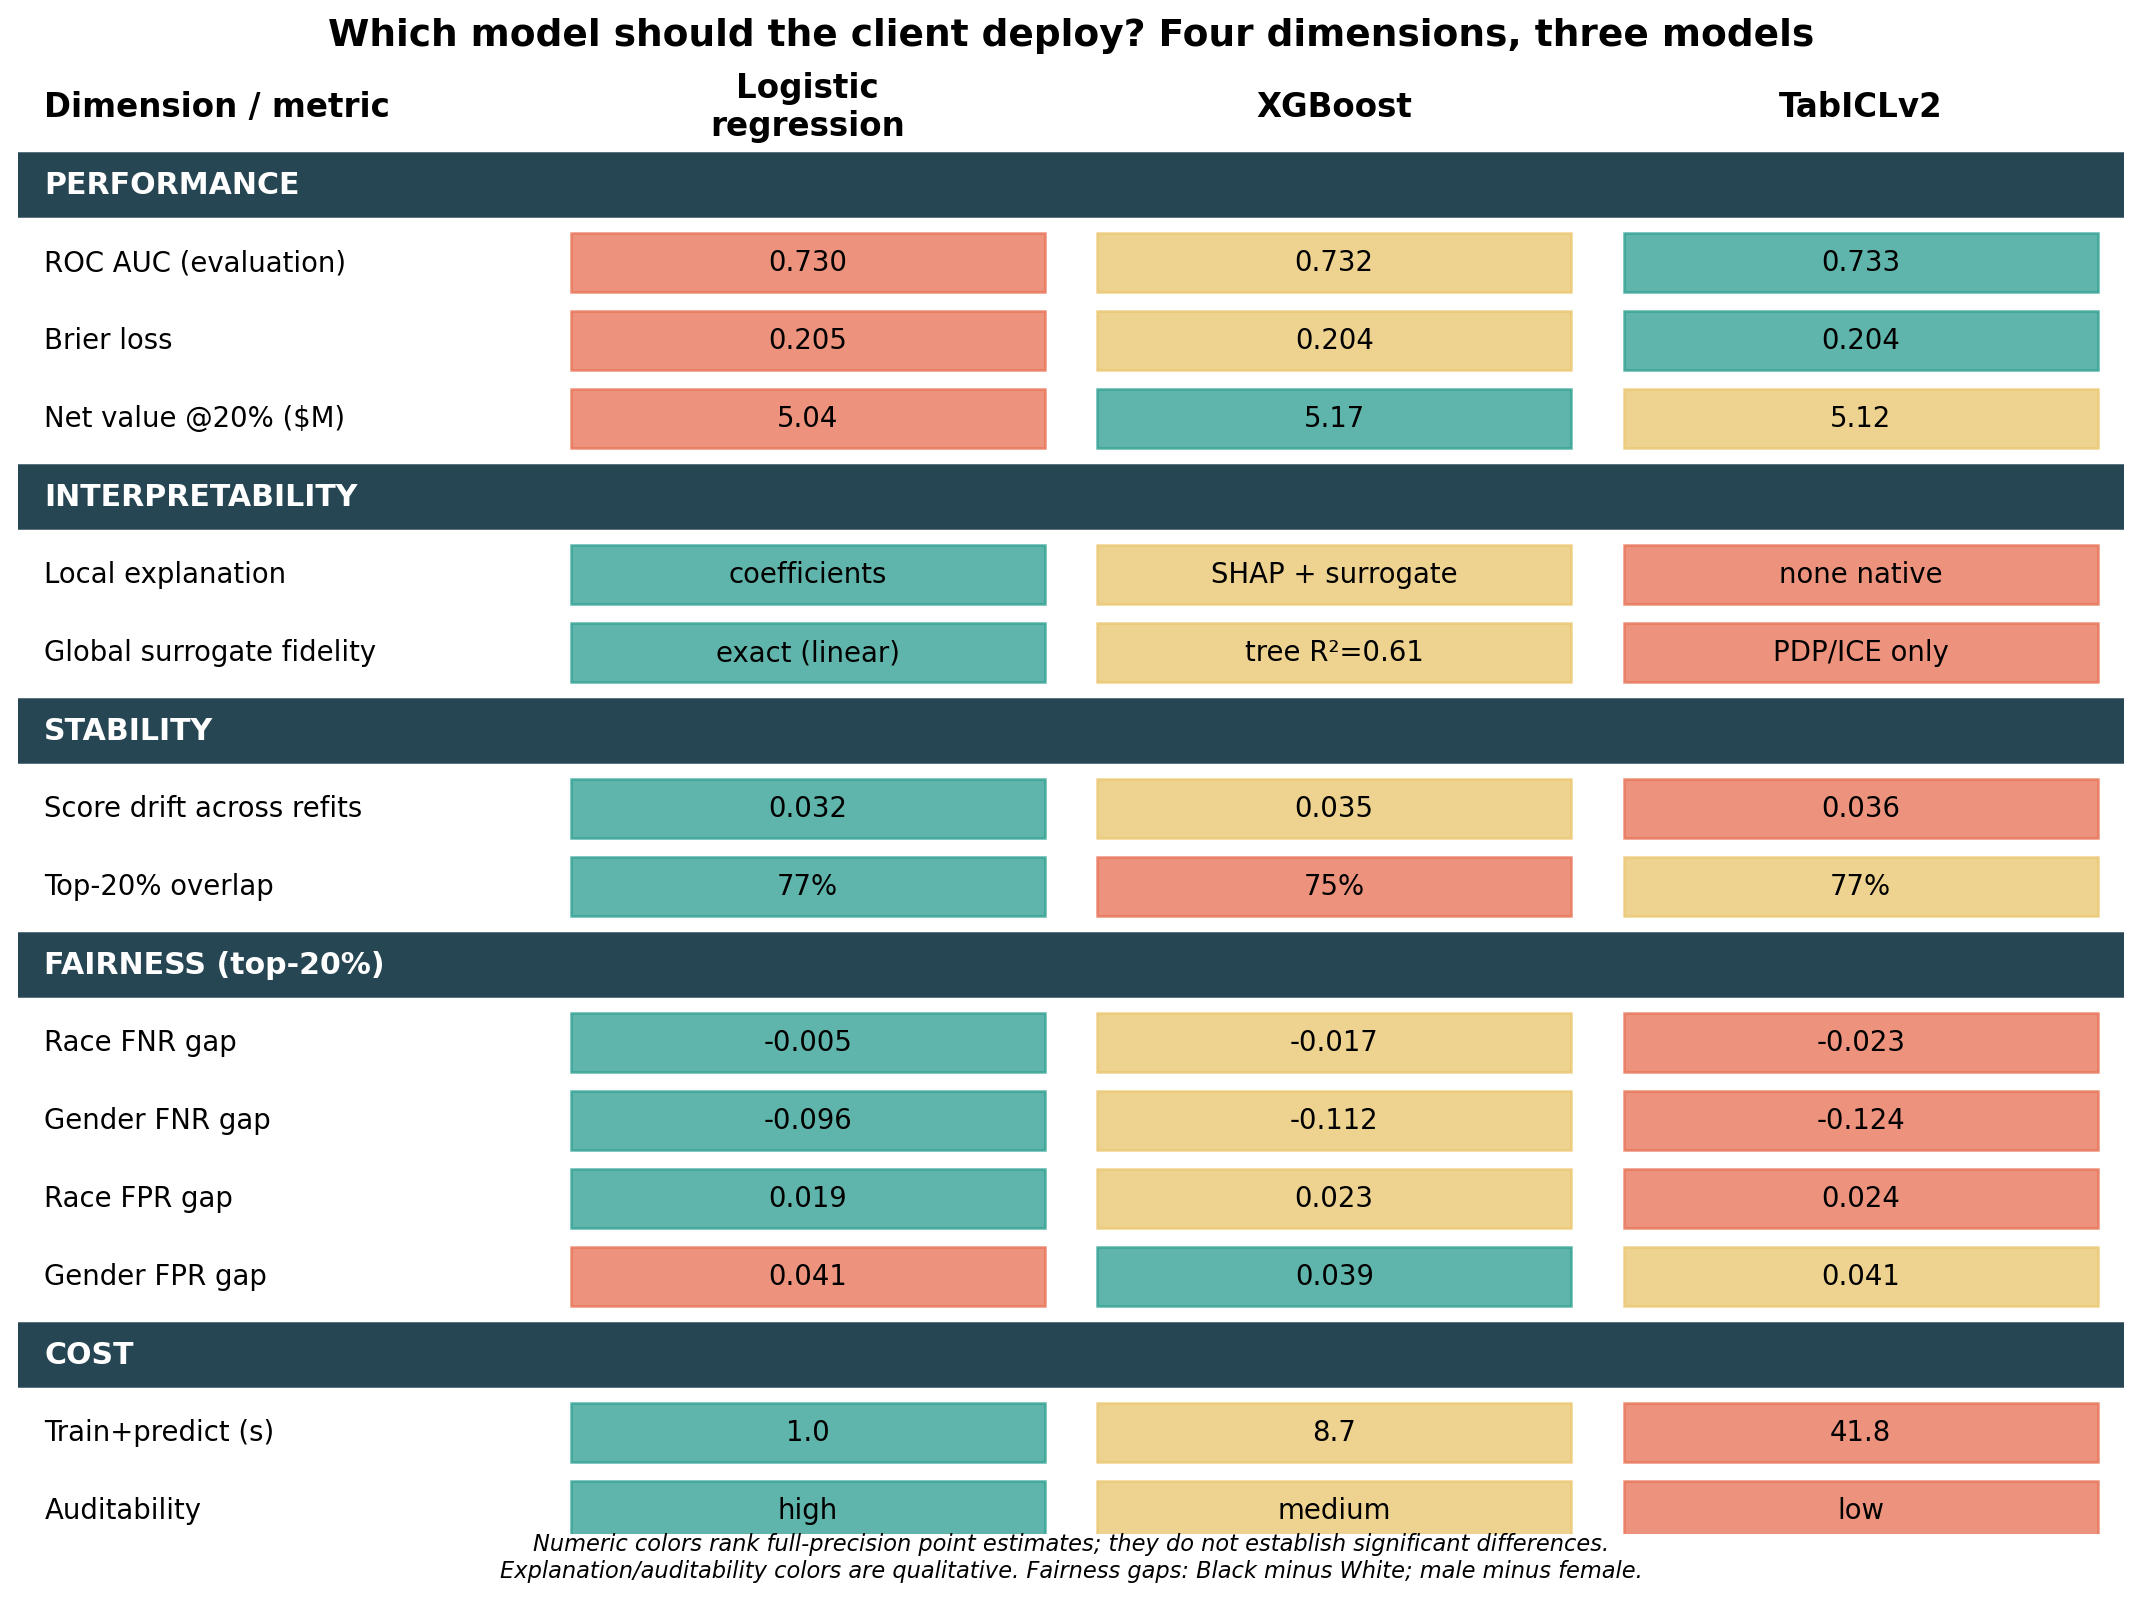

In [22]:
display(Image(filename=str(ROOT / 'artifacts/figures/tradeoff_matrix.png'), width=1000))

## Recommendation

Pilot XGBoost prospectively with logistic as a transparent challenger. Weigh errors, explanation cost, refit stability and runtime together. Small-sample results do not establish suitability for smaller agencies elsewhere. Require independent validation, benefit evidence, corrections/appeals and monitoring before real allocation. No adverse use.

In [23]:
display(json.loads((ROOT/'artifacts/validation_manifest.json').read_text()))

{'python': '3.13.5',
 'cuda_available': True,
 'device': 'NVIDIA GeForce RTX 4050 Laptop GPU',
 'packages': {'numpy': '2.3.2',
  'pandas': '2.3.1',
  'scikit-learn': '1.7.2',
  'xgboost': '3.0.5',
  'tabicl': '2.2.0',
  'torch': '2.10.0+cu130',
  'shap': '0.52.0',
  'streamlit': '1.64.0',
  'lime': '0.2.0.1',
  'XPER': '0.0.92',
  'scipy': '1.16.2',
  'joblib': '1.5.2',
  'python-pptx': '1.0.2',
  'nbformat': '5.10.4',
  'nbclient': '0.10.2'},
 'sha256': {'nij-challenge2021_full_dataset.csv': '2df247209bea3ad2d861ef1624461ef73b5b792f01593da0b6f18e3de1b72f5c',
  'test_predictions.csv': '21e7e6508ec42ad44241ad46da536e6c1729d845530182e7d4f845f57bb7b63e',
  'logistic.joblib': 'a3d1d67429d3251ff334a0ebc6a359bc8fa37034d2e0debccbf9a3d95fc905c1',
  'xgboost.joblib': '609cc8cc53a7937c84c822d10fef70bc41adaa71f8af9f10c0d9fe3a02e90e19'},
 'saved_prediction_max_absolute_error': {'logistic': 1.1102230246251565e-16,
  'xgboost': 2.9800415024539006e-08},
 'official_ids_verified': True,
 'annual_target

References and requirement coverage: reports/research_review.md. Detailed methodological limits: reports/technical_report.md.